# Political Reddit Classification V2 — DeBERTa-v3-base Transformer

Upgrade from the CNN-BiLSTM-Attention baseline (69.19% test accuracy) using a pretrained
transformer with context-aware sentence-pair classification.

**Task (unchanged):** Binary classification of Reddit political text (0 = Democrat, 1 = Republican).  
**Dataset (unchanged):** `political_reddit_context_100k.csv` — 100k balanced rows with thread metadata.  
**Baseline to beat:** Word2Vec CBOW + CNN-BiLSTM-Attention = **69.19%** test accuracy / macro-F1 0.6919.

**Method:**  
- DeBERTa-v3-base fine-tuning with sentence-pair context enrichment  
- Layer-wise LR decay (LLRD 0.95) · FGM adversarial training · label smoothing 0.05  
- Anti-leakage preprocessing · threshold optimization

**Labels:** 0 = Democrat, 1 = Republican.

In [1]:
# # =========================
# # ENVIRONMENT FIX FOR TRANSFORMER RUN
# # Fix torch / transformers / ml_dtypes conflicts
# # =========================

# import sys
# import subprocess
# import os

# def pip_install(cmd):
#     subprocess.check_call([sys.executable, "-m", "pip"] + cmd)

# print("Cleaning conflicting packages...")

# # remove conflicting packages
# packages_to_remove = [
#     "tensorflow",
#     "tensorflow-intel",
#     "jax",
#     "jaxlib",
#     "ml_dtypes",
# ]

# for pkg in packages_to_remove:
#     try:
#         pip_install(["uninstall", "-y", pkg])
#     except:
#         pass

# print("Installing clean compatible stack...")

# # PyTorch CUDA build
# pip_install([
#     "install",
#     "--upgrade",
#     "torch",
#     "torchvision",
#     "torchaudio",
#     "--index-url",
#     "https://download.pytorch.org/whl/cu121"
# ])

# # transformers stack
# pip_install([
#     "install",
#     "--upgrade",
#     "transformers==4.41.2",
#     "accelerate==0.30.1",
#     "sentencepiece",
#     "scikit-learn",
#     "pandas",
#     "numpy",
#     "matplotlib",
#     "seaborn",
#     "tqdm",
# ])

# # fix exact dependency
# pip_install([
#     "install",
#     "ml_dtypes==0.4.0"
# ])

# print("\nEnvironment fixed successfully.")
# print("IMPORTANT: Restart kernel NOW before continuing.")

# # hard exit to force clean reload
# os._exit(0)

## 1. Setup and Dependencies

In [2]:
import importlib, subprocess, sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# ── Ensure CUDA-enabled PyTorch ──
try:
    import torch
    if not torch.cuda.is_available() and not IN_COLAB:
        print('WARNING: torch is installed but CUDA is not available.')
        print('If you have an NVIDIA GPU, install the CUDA build:')
        print('  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121')
except ImportError:
    if IN_COLAB:
        pass  # Colab has torch pre-installed
    else:
        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q',
            'torch', 'torchvision', 'torchaudio',
            '--index-url', 'https://download.pytorch.org/whl/cu121',
        ])

REQUIRED = {
    'transformers':  'transformers>=4.41,<5',
    'datasets':      'datasets>=2.18',
    'accelerate':    'accelerate>=0.27',
    'sentencepiece': 'sentencepiece',
    'tokenizers':    'tokenizers',
    'sklearn':       'scikit-learn',
    'pandas':        'pandas',
    'numpy':         'numpy',
    'matplotlib':    'matplotlib',
    'seaborn':       'seaborn',
    'tqdm':          'tqdm',
}

missing = []
for mod, spec in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(spec)
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print('Dependencies OK.')

If you have an NVIDIA GPU, install the CUDA build:
  pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
Dependencies OK.


## 2. Imports

In [3]:
import os, re, json, math, random, gc, time, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
)

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='paper')
plt.rcParams['figure.dpi'] = 110

print('Transformers:', transformers.__version__)
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', f'{torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow.')

Transformers: 4.40.1
Torch: 2.2.2+cpu | CUDA: False


## 3. Configuration

In [4]:
SEED = 42

try:
    import google.colab
    IN_COLAB = True
    PROJECT_ROOT = Path('/content')
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT = Path(r'D:\PROJECTS\NLP - PROJECT')

CONFIG = {
    # Paths
    'DATA_PATH': str(PROJECT_ROOT / 'political_reddit_context_100k.csv'),
    'ARTIFACTS_DIR': str(PROJECT_ROOT / 'artifacts_v2'),

    # Model
    'MODEL_NAME': 'microsoft/deberta-v3-base',
    'MAX_SEQ_LEN': 256,
    'NUM_LABELS': 2,

    # Training
    'EPOCHS': 4,
    'MICRO_BATCH_SIZE': 4,
    'GRADIENT_ACCUMULATION_STEPS': 8,  # effective batch = 32
    'LEARNING_RATE': 2e-5,
    'LR_HEAD': 1e-4,
    'LLRD_FACTOR': 0.95,
    'WEIGHT_DECAY': 0.01,
    'WARMUP_RATIO': 0.06,
    'MAX_GRAD_NORM': 1.0,
    'LABEL_SMOOTHING': 0.05,

    # FGM
    'USE_FGM': True,
    'FGM_EPSILON': 1.0,
    'FGM_EMB_NAME': 'deberta.embeddings.word_embeddings',

    # Memory
    'FP16': True,
    'GRADIENT_CHECKPOINTING': False,  # enable if OOM

    # Split
    'TEST_SIZE': 0.10,
    'VAL_SIZE_OF_REMAINDER': 1.0 / 9.0,  # => 80/10/10
    'SEED': SEED,

    # Evaluation
    'EVAL_BATCH_SIZE': 8,
    'PATIENCE_ES': 2,

    # Baseline reference
    'BASELINE_ACC': 0.6919,
    'BASELINE_F1': 0.6919,
    'BASELINE_THR': 0.510,
    'BASELINE_CTX_ACC': 0.80873,
    'BASELINE_NOCTX_ACC': 0.67506,
}

Path(CONFIG['ARTIFACTS_DIR']).mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Artifacts dir:', CONFIG['ARTIFACTS_DIR'])
print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=2))

Project root: D:\PROJECTS\NLP - PROJECT
Artifacts dir: D:\PROJECTS\NLP - PROJECT\artifacts_v2
{
  "DATA_PATH": "D:\\PROJECTS\\NLP - PROJECT\\political_reddit_context_100k.csv",
  "ARTIFACTS_DIR": "D:\\PROJECTS\\NLP - PROJECT\\artifacts_v2",
  "MODEL_NAME": "microsoft/deberta-v3-base",
  "MAX_SEQ_LEN": "256",
  "NUM_LABELS": "2",
  "EPOCHS": "4",
  "MICRO_BATCH_SIZE": "4",
  "GRADIENT_ACCUMULATION_STEPS": "8",
  "LEARNING_RATE": "2e-05",
  "LR_HEAD": "0.0001",
  "LLRD_FACTOR": "0.95",
  "WEIGHT_DECAY": "0.01",
  "WARMUP_RATIO": "0.06",
  "MAX_GRAD_NORM": "1.0",
  "LABEL_SMOOTHING": "0.05",
  "USE_FGM": "True",
  "FGM_EPSILON": "1.0",
  "FGM_EMB_NAME": "deberta.embeddings.word_embeddings",
  "FP16": "True",
  "GRADIENT_CHECKPOINTING": "False",
  "TEST_SIZE": "0.1",
  "VAL_SIZE_OF_REMAINDER": "0.1111111111111111",
  "SEED": "42",
  "EVAL_BATCH_SIZE": "8",
  "PATIENCE_ES": "2",
  "BASELINE_ACC": "0.6919",
  "BASELINE_F1": "0.6919",
  "BASELINE_THR": "0.51",
  "BASELINE_CTX_ACC": "0.80873",

## 4. Reproducibility + Precision Detection

In [5]:
def set_global_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_global_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def detect_precision():
    if not torch.cuda.is_available():
        return False, False
    try:
        cap_major = torch.cuda.get_device_capability(0)[0]
        if cap_major >= 8:
            x = torch.zeros(2, dtype=torch.bfloat16, device='cuda')
            del x
            return True, False
    except Exception:
        pass
    try:
        x = torch.zeros(2, dtype=torch.float16, device='cuda')
        del x
        return False, True
    except Exception:
        return False, False


USE_BF16, USE_FP16 = detect_precision()
if USE_BF16:
    CONFIG['FP16'] = False
    AMP_DTYPE = torch.bfloat16
elif USE_FP16:
    CONFIG['FP16'] = True
    AMP_DTYPE = torch.float16
else:
    CONFIG['FP16'] = False
    AMP_DTYPE = torch.float32

print(f'Device: {DEVICE}')
print(f'Precision: bf16={USE_BF16}, fp16={USE_FP16}')
print(f'AMP dtype: {AMP_DTYPE}')
print(f'Seed: {SEED}')

Device: cpu
Precision: bf16=False, fp16=False
AMP dtype: torch.float32
Seed: 42


## 5. Data Loading

In [6]:
df = pd.read_csv(
    CONFIG['DATA_PATH'],
    dtype={'id': str, 'root': str, 'reply_to': str},
)
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nFirst rows:')
df.head()

Shape: (100000, 5)

Dtypes:
id          object
root        object
reply_to    object
text        object
label        int64
dtype: object

First rows:


,id,root,reply_to,text,label
0,e0icvw4,8q9bva,e0iaqq4,Do you consider CNN to be?,1
1,cwywp2l,3skvz0,cwyw88z,Where did the liberal touch you? \n\nShow me ...,1
2,d9xj9u3,5ck8j0,5ck8j0,We do need to apologize for some things. The ...,0
3,dwiox1t,881zb4,dwhlw01,My old high school had a bunch of pickup truck...,1
4,c6iviy1,10zuhi,c6i9vp6,You can...until you can't. What you're describ...,1


## 6. Integrity Checks

In [7]:
required = {'text', 'label', 'id', 'root', 'reply_to'}
missing = required - set(df.columns)
assert not missing, f'Missing columns: {missing}'

df['label'] = df['label'].astype(int)
print('Label values:', sorted(df['label'].unique()))
assert set(df['label'].unique()) == {0, 1}

print('\nClass counts:')
print(df['label'].value_counts())

print('\nNull counts per column:')
print(df.isnull().sum())

deleted_count = (df['text'] == '[deleted]').sum()
removed_count = (df['text'] == '[removed]').sum()
print(f'\n[deleted] in text: {deleted_count}')
print(f'[removed] in text: {removed_count}')

Label values: [0, 1]

Class counts:
label
1    50000
0    50000
Name: count, dtype: int64

Null counts per column:
id             0
root           0
reply_to    1129
text           0
label          0
dtype: int64

[deleted] in text: 0
[removed] in text: 0


## 7. Compact EDA

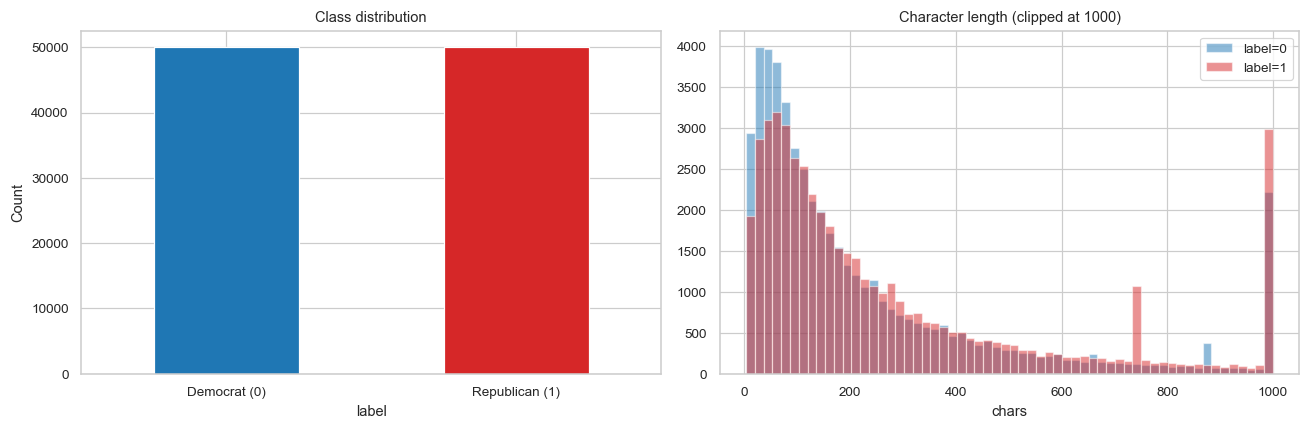

Character length stats per class:
         count       mean         std  min   25%    50%    75%      max
label                                                                  
0      50000.0  270.96002  492.701436  3.0  59.0  132.0  296.0  20511.0
1      50000.0  318.31910  478.400296  3.0  77.0  167.0  366.0  13178.0


In [8]:
df['_char_len'] = df['text'].astype(str).str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['tab:blue', 'tab:red']
)
axes[0].set_xticklabels(['Democrat (0)', 'Republican (1)'], rotation=0)
axes[0].set_title('Class distribution')
axes[0].set_ylabel('Count')

for lbl, color in [(0, 'tab:blue'), (1, 'tab:red')]:
    axes[1].hist(
        df.loc[df['label'] == lbl, '_char_len'].clip(upper=1000),
        bins=60, alpha=0.5, label=f'label={lbl}', color=color,
    )
axes[1].set_title('Character length (clipped at 1000)')
axes[1].legend()
axes[1].set_xlabel('chars')
plt.tight_layout()
plt.show()

print('Character length stats per class:')
print(df.groupby('label')['_char_len'].describe())
df = df.drop(columns=['_char_len'])

## 8. Context Enrichment (before splitting — matches baseline)

Build `id_to_text` lookup from ALL 100k rows, then enrich comments with their parent text.  
Two-tier resolution: `reply_to` first (parent comment), then `root` fallback (root post).  
Context text is stored separately from comment text for sentence-pair tokenization.

In [9]:
def is_usable_text(t):
    if not isinstance(t, str):
        return False
    s = t.strip()
    return s != '' and s != '[deleted]' and s != '[removed]'


for col in ['id', 'root', 'reply_to']:
    df[col] = df[col].astype('string').str.strip()
df.loc[df['reply_to'].isin(['', 'nan', 'None', 'NaN', '<NA>']), 'reply_to'] = pd.NA
df.loc[df['root'].isin(['', 'nan', 'None', 'NaN', '<NA>']), 'root'] = pd.NA

# Build full id -> text lookup over every usable row
usable_mask = df['text'].apply(is_usable_text)
usable_df = df[usable_mask]

id_to_text = {}
for rid, txt in zip(usable_df['id'].tolist(), usable_df['text'].tolist()):
    if rid is pd.NA or rid is None:
        continue
    if rid not in id_to_text:
        id_to_text[rid] = txt

print(f'Total rows:      {len(df)}')
print(f'Usable rows:     {len(usable_df)}')
print(f'id_to_text size: {len(id_to_text)}')

Total rows:      100000
Usable rows:     100000
id_to_text size: 100000


In [10]:
def resolve_context(row):
    """Return (context_text, tier) for a row."""
    rid = row['reply_to']
    if pd.notna(rid) and rid != row['id'] and rid in id_to_text:
        parent_txt = id_to_text[rid]
        if is_usable_text(parent_txt):
            return parent_txt, 'parent'
    rt = row['root']
    if pd.notna(rt) and rt != row['id'] and rt in id_to_text:
        root_txt = id_to_text[rt]
        if is_usable_text(root_txt):
            return root_txt, 'root'
    return '', 'none'


def build_enriched(row):
    """Return (comment_text, context_text_or_empty, has_context, tier)."""
    txt = row['text'] if isinstance(row['text'], str) else ''
    if row['id'] == row['root'] or pd.isna(row['reply_to']):
        return txt, '', False, 'self'
    ctx, tier = resolve_context(row)
    if tier == 'none' or not ctx:
        return txt, '', False, 'none'
    return txt, ctx, True, tier


results = df.apply(build_enriched, axis=1)
df['comment_text'] = [r[0] for r in results]
df['context_text'] = [r[1] for r in results]
df['has_context']  = [r[2] for r in results]
df['ctx_tier']     = [r[3] for r in results]

print('has_context distribution:')
print(df['has_context'].value_counts())
print(f'\nContext hit rate: {df["has_context"].mean():.4f}')
print('\nctx_tier distribution:')
print(df['ctx_tier'].value_counts())
print('\nMean has_context per label:')
print(df.groupby('label')['has_context'].mean())

has_context distribution:
has_context
False    87425
True     12575
Name: count, dtype: int64

Context hit rate: 0.1258

ctx_tier distribution:
ctx_tier
none      86296
parent    11149
root       1426
self       1129
Name: count, dtype: int64

Mean has_context per label:
label
0    0.1272
1    0.1243
Name: has_context, dtype: float64


## 9. Transformer Preprocessing

Minimal text cleaning. NO lemmatization, NO stopword removal, NO lowercasing.  
Anti-leakage: scrub subreddit names and user mentions.  
Applied to comment text and context text **separately** (for sentence-pair tokenization).

In [11]:
_URL_RE   = re.compile(r'https?://\S+|www\.\S+')
_USER_RE  = re.compile(r'/u/[A-Za-z0-9_\-]+|\bu/[A-Za-z0-9_\-]+')
_SUB_RE   = re.compile(r'/r/[A-Za-z0-9_\-]+|\br/[A-Za-z0-9_\-]+')
_MD_BOLD  = re.compile(r'\*{1,3}|_{2,}')
_QUOTE_LN = re.compile(r'^\s*>\s?', re.MULTILINE)
_WS_RE    = re.compile(r'\s+')


def preprocess_transformer(text: str) -> str:
    if not isinstance(text, str):
        return ''
    t = text.strip()
    if t in ('[deleted]', '[removed]', ''):
        return ''
    t = _URL_RE.sub(' [URL] ', t)
    t = _SUB_RE.sub(' [SUBREDDIT] ', t)
    t = _USER_RE.sub(' [USER] ', t)
    t = _QUOTE_LN.sub('', t)
    t = _MD_BOLD.sub('', t)
    t = _WS_RE.sub(' ', t).strip()
    return t


# Sanity check
for s in [
    'I support /r/democrats -- see https://example.com by /u/foo',
    'MAGA!!! Sooooo proud, check /r/Republicans',
    '> This is a quote\n> with two lines',
]:
    print(repr(s), '->', repr(preprocess_transformer(s)))

'I support /r/democrats -- see https://example.com by /u/foo' -> 'I support [SUBREDDIT] -- see [URL] by [USER]'
'MAGA!!! Sooooo proud, check /r/Republicans' -> 'MAGA!!! Sooooo proud, check [SUBREDDIT]'
'> This is a quote\n> with two lines' -> 'This is a quote with two lines'


In [12]:
tqdm.pandas(desc='Preprocessing comments')
df['comment_clean'] = df['comment_text'].progress_apply(preprocess_transformer)

tqdm.pandas(desc='Preprocessing context')
df['context_clean'] = df['context_text'].progress_apply(preprocess_transformer)

# Drop rows where comment becomes empty after preprocessing
empty_mask = df['comment_clean'].str.len() == 0
print(f'Empty after preprocessing: {empty_mask.sum()}')
df = df[~empty_mask].reset_index(drop=True)
print(f'Remaining rows: {len(df)}')

print('\nSample preprocessed rows:')
for i in range(3):
    print(f'\nrow {i} label={df["label"].iloc[i]}')
    print(f'  comment: {df["comment_clean"].iloc[i][:200]}')
    if df['has_context'].iloc[i]:
        print(f'  context: {df["context_clean"].iloc[i][:200]}')

Preprocessing comments:   0%|          | 0/100000 [00:00<?, ?it/s]

Preprocessing context:   0%|          | 0/100000 [00:00<?, ?it/s]

Empty after preprocessing: 0
Remaining rows: 100000

Sample preprocessed rows:

row 0 label=1
  comment: Do you consider CNN to be?

row 1 label=1
  comment: Where did the liberal touch you? Show me on the constitution? Was it the free healthcare? or the single issue voter complex again? or Supreme Court justice concerns?
  context: I think the last thing we're trying to do here is create a "safe space" lol.

row 2 label=0
  comment: We do need to apologize for some things. The fact of the matter is that we have alienated the working class from the political system. We will talk about police killing blacks, but we will not commit 


## 10. Stratified 80/10/10 Split (identical to baseline)

In [13]:
train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG['TEST_SIZE'],
    stratify=df['label'],
    random_state=SEED,
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=CONFIG['VAL_SIZE_OF_REMAINDER'],
    stratify=train_val_df['label'],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

n_total = len(train_df) + len(val_df) + len(test_df)
print(f'Train: {len(train_df):>6} ({len(train_df)/n_total:.2%})')
print(f'Val:   {len(val_df):>6} ({len(val_df)/n_total:.2%})')
print(f'Test:  {len(test_df):>6} ({len(test_df)/n_total:.2%})')

print('\nLabel balance per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["label"].value_counts(normalize=True).round(4).to_dict()}')

print('\nhas_context fraction per split:')
for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name}: {split["has_context"].mean():.4f}')

Train:  80000 (80.00%)
Val:    10000 (10.00%)
Test:   10000 (10.00%)

Label balance per split:
  train: {1: 0.5, 0: 0.5}
  val: {0: 0.5, 1: 0.5}
  test: {0: 0.5, 1: 0.5}

has_context fraction per split:
  train: 0.1245
  val: 0.1357
  test: 0.1254


## 11. Tokenizer + Token-Length Profiling

Tokenizer: microsoft/deberta-v3-base
Vocab size: 128000

Comment-only token lengths (n=10000):
  mean=64.0  median=34  P90=142  P95=215  P99=457  max=1969

Comment+context token lengths (n=2000):
  mean=166.3  median=100  P90=352  P95=506  P99=1089  max=2124

Chosen MAX_SEQ_LEN: 256
Truncation rate (comment-only): 3.41%
Truncation rate (with context): 16.35%


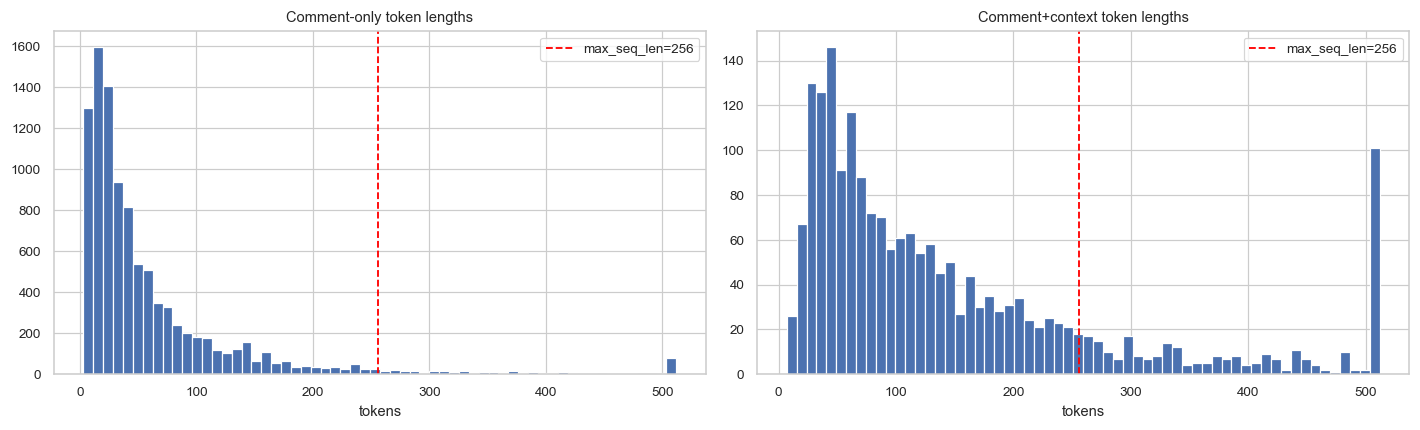

In [14]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['MODEL_NAME'], use_fast=True)
print(f'Tokenizer: {CONFIG["MODEL_NAME"]}')
print(f'Vocab size: {tokenizer.vocab_size}')

# Profile comment-only token lengths
sample_comments = train_df['comment_clean'].sample(
    min(10000, len(train_df)), random_state=0
).tolist()
comment_lens = np.array([
    len(x) for x in tokenizer(
        sample_comments, add_special_tokens=True, truncation=False
    )['input_ids']
])
print(f'\nComment-only token lengths (n={len(comment_lens)}):')
print(f'  mean={comment_lens.mean():.1f}  median={np.median(comment_lens):.0f}  '
      f'P90={np.quantile(comment_lens, 0.90):.0f}  P95={np.quantile(comment_lens, 0.95):.0f}  '
      f'P99={np.quantile(comment_lens, 0.99):.0f}  max={comment_lens.max()}')

# Profile comment+context combined lengths
ctx_sample = train_df[train_df['has_context']].sample(
    min(2000, train_df['has_context'].sum()), random_state=0
)
if len(ctx_sample) > 0:
    combined_lens = np.array([
        len(tokenizer(
            row['comment_clean'], row['context_clean'],
            add_special_tokens=True, truncation=False
        )['input_ids'])
        for _, row in ctx_sample.iterrows()
    ])
    print(f'\nComment+context token lengths (n={len(combined_lens)}):')
    print(f'  mean={combined_lens.mean():.1f}  median={np.median(combined_lens):.0f}  '
          f'P90={np.quantile(combined_lens, 0.90):.0f}  P95={np.quantile(combined_lens, 0.95):.0f}  '
          f'P99={np.quantile(combined_lens, 0.99):.0f}  max={combined_lens.max()}')

print(f'\nChosen MAX_SEQ_LEN: {CONFIG["MAX_SEQ_LEN"]}')
print(f'Truncation rate (comment-only): {(comment_lens > CONFIG["MAX_SEQ_LEN"]).mean()*100:.2f}%')
if len(ctx_sample) > 0:
    print(f'Truncation rate (with context): {(combined_lens > CONFIG["MAX_SEQ_LEN"]).mean()*100:.2f}%')

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.clip(comment_lens, 0, 512), bins=60)
axes[0].axvline(CONFIG['MAX_SEQ_LEN'], color='red', linestyle='--',
                label=f'max_seq_len={CONFIG["MAX_SEQ_LEN"]}')
axes[0].set_title('Comment-only token lengths')
axes[0].set_xlabel('tokens'); axes[0].legend()

if len(ctx_sample) > 0:
    axes[1].hist(np.clip(combined_lens, 0, 512), bins=60)
    axes[1].axvline(CONFIG['MAX_SEQ_LEN'], color='red', linestyle='--',
                    label=f'max_seq_len={CONFIG["MAX_SEQ_LEN"]}')
    axes[1].set_title('Comment+context token lengths')
    axes[1].set_xlabel('tokens'); axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Dataset Preparation

In [15]:
class PoliticalDataset(Dataset):
    def __init__(self, comments, contexts, labels, has_context, tokenizer, max_length):
        self.comments = comments
        self.contexts = contexts
        self.labels = labels
        self.has_context = has_context
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.comments)

    def __getitem__(self, idx):
        comment = self.comments[idx]
        context = self.contexts[idx]
        label = self.labels[idx]

        if self.has_context[idx] and context and len(context.strip()) > 0:
            encoding = self.tokenizer(
                comment, context,
                truncation='longest_first',
                max_length=self.max_length,
                padding=False,
                return_tensors=None,
            )
        else:
            encoding = self.tokenizer(
                comment,
                truncation=True,
                max_length=self.max_length,
                padding=False,
                return_tensors=None,
            )
        encoding['labels'] = label
        return encoding


def build_dataset(split_df, tokenizer, max_length):
    return PoliticalDataset(
        comments=split_df['comment_clean'].tolist(),
        contexts=split_df['context_clean'].tolist(),
        labels=split_df['label'].tolist(),
        has_context=split_df['has_context'].tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )


train_dataset = build_dataset(train_df, tokenizer, CONFIG['MAX_SEQ_LEN'])
val_dataset   = build_dataset(val_df,   tokenizer, CONFIG['MAX_SEQ_LEN'])
test_dataset  = build_dataset(test_df,  tokenizer, CONFIG['MAX_SEQ_LEN'])

collator = DataCollatorWithPadding(tokenizer, padding=True, return_tensors='pt')

print(f'Train: {len(train_dataset)}')
print(f'Val:   {len(val_dataset)}')
print(f'Test:  {len(test_dataset)}')

# Verify a sample
sample = train_dataset[0]
print(f'\nSample keys: {list(sample.keys())}')
print(f'input_ids length: {len(sample["input_ids"])}')
print(f'Decoded: {tokenizer.decode(sample["input_ids"][:80])}...')

Train: 80000
Val:   10000
Test:  10000

Sample keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids length: 64
Decoded: [CLS] Some are more dickish than others - especially the ones calling for assassination.[SEP] What is the point of this? Are these offical green party posters or progressive leader's quotes or somthing? Or is this just some random posters? Maybe you are saying that people of all political affiliation can be dickish?[SEP]...


## 13. VRAM Memory Probe

In [16]:
def print_gpu_mem(tag=''):
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        total = torch.cuda.get_device_properties(0).total_mem / 1024**3
        print(f'[{tag}] GPU memory: {alloc:.2f}GB allocated, '
              f'{reserved:.2f}GB reserved, {total:.1f}GB total')


if torch.cuda.is_available():
    print('Running VRAM probe...')
    torch.cuda.empty_cache()
    gc.collect()

    probe_model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['MODEL_NAME'], num_labels=CONFIG['NUM_LABELS']
    ).to(DEVICE)
    if AMP_DTYPE != torch.float32:
        probe_model = probe_model.half() if AMP_DTYPE == torch.float16 else probe_model.bfloat16()
    print_gpu_mem('model loaded')

    # Simulate a forward pass with max-length batch
    dummy_input = tokenizer(
        ['test sentence'] * CONFIG['MICRO_BATCH_SIZE'],
        padding='max_length',
        max_length=CONFIG['MAX_SEQ_LEN'],
        return_tensors='pt',
    ).to(DEVICE)
    dummy_labels = torch.zeros(CONFIG['MICRO_BATCH_SIZE'], dtype=torch.long, device=DEVICE)

    with torch.cuda.amp.autocast(enabled=(AMP_DTYPE != torch.float32)):
        try:
            probe_model.float()  # back to fp32 for autocast
            output = probe_model(**dummy_input, labels=dummy_labels)
            output.loss.backward()
            print_gpu_mem('after forward+backward')
            print('VRAM probe PASSED. Configuration is safe.')
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print('WARNING: OOM detected. Enabling gradient checkpointing...')
                CONFIG['GRADIENT_CHECKPOINTING'] = True
                torch.cuda.empty_cache()
            else:
                raise

    del probe_model, dummy_input, dummy_labels
    gc.collect()
    torch.cuda.empty_cache()
    print_gpu_mem('after cleanup')
else:
    print('No GPU available. VRAM probe skipped.')
    print('Training will run on CPU (slow but functional).')

No GPU available. VRAM probe skipped.
Training will run on CPU (slow but functional).


## 14. Model + Optimizer Setup

In [17]:
def build_llrd_param_groups(
    model: nn.Module,
    base_lr: float,
    head_lr: float,
    decay: float,
    weight_decay: float,
    n_layers: Optional[int] = None,
) -> List[Dict]:
    if n_layers is None:
        n_layers = model.config.num_hidden_layers

    no_decay = ('bias', 'LayerNorm.weight', 'LayerNorm.bias')
    def _wd(n):
        return 0.0 if any(nd in n for nd in no_decay) else weight_decay

    groups, seen = [], set()

    # Head + pooler
    head_d, head_nd = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if n.startswith('classifier') or n.startswith('pooler'):
            (head_nd if _wd(n) == 0 else head_d).append(p)
            seen.add(n)
    if head_d:
        groups.append({'params': head_d, 'lr': head_lr, 'weight_decay': weight_decay})
    if head_nd:
        groups.append({'params': head_nd, 'lr': head_lr, 'weight_decay': 0.0})

    # Encoder layers (top -> bottom)
    for layer_i in reversed(range(n_layers)):
        layer_lr = base_lr * (decay ** (n_layers - 1 - layer_i))
        d_p, nd_p = [], []
        prefix = f'encoder.layer.{layer_i}.'
        for n, p in model.named_parameters():
            if not p.requires_grad or n in seen:
                continue
            if prefix in n:
                (nd_p if _wd(n) == 0 else d_p).append(p)
                seen.add(n)
        if d_p:
            groups.append({'params': d_p, 'lr': layer_lr, 'weight_decay': weight_decay})
        if nd_p:
            groups.append({'params': nd_p, 'lr': layer_lr, 'weight_decay': 0.0})

    # Embeddings + remainder
    bottom_lr = base_lr * (decay ** n_layers)
    r_d, r_nd = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad or n in seen:
            continue
        (r_nd if _wd(n) == 0 else r_d).append(p)
    if r_d:
        groups.append({'params': r_d, 'lr': bottom_lr, 'weight_decay': weight_decay})
    if r_nd:
        groups.append({'params': r_nd, 'lr': bottom_lr, 'weight_decay': 0.0})

    n_grouped = sum(len(g['params']) for g in groups)
    n_total = sum(1 for _, p in model.named_parameters() if p.requires_grad)
    assert n_grouped == n_total, f'LLRD coverage: {n_grouped} vs {n_total}'
    return groups


print('LLRD builder ready.')

LLRD builder ready.


In [18]:
set_global_seed(SEED)

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['MODEL_NAME'],
    num_labels=CONFIG['NUM_LABELS'],
)
model = model.to(DEVICE)

if CONFIG['GRADIENT_CHECKPOINTING']:
    model.gradient_checkpointing_enable()
    print('Gradient checkpointing enabled.')

# LLRD optimizer
param_groups = build_llrd_param_groups(
    model,
    base_lr=CONFIG['LEARNING_RATE'],
    head_lr=CONFIG['LR_HEAD'],
    decay=CONFIG['LLRD_FACTOR'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
)
optimizer = torch.optim.AdamW(param_groups, lr=CONFIG['LEARNING_RATE'], eps=1e-8)

# Scheduler
steps_per_epoch = math.ceil(len(train_dataset) / CONFIG['MICRO_BATCH_SIZE'])
total_steps = (steps_per_epoch // CONFIG['GRADIENT_ACCUMULATION_STEPS']) * CONFIG['EPOCHS']
warmup_steps = int(total_steps * CONFIG['WARMUP_RATIO'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = torch.cuda.amp.GradScaler(enabled=(AMP_DTYPE == torch.float16))

print(f'Total params: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable:    {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Steps/epoch:  {steps_per_epoch}')
print(f'Total optim steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print_gpu_mem('model ready')

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total params: 184,423,682
Trainable:    184,423,682
Steps/epoch:  20000
Total optim steps: 10000
Warmup steps: 600


## 15. FGM Adversarial Training

In [19]:
class FGM:
    """Fast Gradient Method adversarial perturbation on word embeddings."""

    def __init__(self, model: nn.Module, epsilon: float = 1.0,
                 emb_name: str = 'deberta.embeddings.word_embeddings'):
        self.model = model
        self.epsilon = epsilon
        self.emb_name = emb_name
        self.backup: Dict[str, torch.Tensor] = {}

    def attack(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name and param.grad is not None:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    r_at = self.epsilon * param.grad / norm
                    param.data.add_(r_at)

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}


fgm = FGM(model, epsilon=CONFIG['FGM_EPSILON'], emb_name=CONFIG['FGM_EMB_NAME'])
print(f'FGM ready. epsilon={CONFIG["FGM_EPSILON"]}, emb_name={CONFIG["FGM_EMB_NAME"]}')
print(f'FGM enabled: {CONFIG["USE_FGM"]}')

FGM ready. epsilon=1.0, emb_name=deberta.embeddings.word_embeddings
FGM enabled: True


## 16. Training Loop

In [20]:
# Label-smoothing cross-entropy
loss_fn = nn.CrossEntropyLoss(label_smoothing=CONFIG['LABEL_SMOOTHING'])


@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    n_batches = 0
    for batch in dataloader:
        labels = batch.pop('labels').to(device)
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.cuda.amp.autocast(enabled=(AMP_DTYPE != torch.float32)):
            outputs = model(**batch)
        logits = outputs.logits
        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item()
        n_batches += 1
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    return {
        'loss': total_loss / max(n_batches, 1),
        'accuracy': float(accuracy_score(all_labels, all_preds)),
        'f1_macro': float(f1_score(all_labels, all_preds, average='macro')),
    }


# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['MICRO_BATCH_SIZE'],
    shuffle=True,
    collate_fn=collator,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['EVAL_BATCH_SIZE'],
    shuffle=False,
    collate_fn=collator,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Effective batch size: {CONFIG["MICRO_BATCH_SIZE"] * CONFIG["GRADIENT_ACCUMULATION_STEPS"]}')

Train batches: 20000
Val batches:   1250
Effective batch size: 32


In [ ]:
best_model_dir = os.path.join(CONFIG['ARTIFACTS_DIR'], 'best_model')
Path(best_model_dir).mkdir(parents=True, exist_ok=True)

history = {'train_loss': [], 'val_loss': [], 'val_accuracy': [], 'val_f1_macro': [], 'lr': []}
best_val_f1 = 0.0
patience_counter = 0
use_amp = (AMP_DTYPE != torch.float32)

print(f'Starting training for {CONFIG["EPOCHS"]} epochs...')
print(f'FGM: {CONFIG["USE_FGM"]} | FP16: {use_amp} | '
      f'Grad accum: {CONFIG["GRADIENT_ACCUMULATION_STEPS"]} | '
      f'Grad ckpt: {CONFIG["GRADIENT_CHECKPOINTING"]}')
print('=' * 70)

t0_total = time.time()

for epoch in range(CONFIG['EPOCHS']):
    t0_epoch = time.time()
    model.train()
    optimizer.zero_grad()
    epoch_loss = 0.0
    n_optim_steps = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{CONFIG["EPOCHS"]}')
    for step, batch in enumerate(pbar):
        labels = batch.pop('labels').to(DEVICE)
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        # Forward + backward (clean)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            loss = loss / CONFIG['GRADIENT_ACCUMULATION_STEPS']
        scaler.scale(loss).backward()

        # FGM adversarial step
        if CONFIG['USE_FGM']:
            fgm.attack()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs_adv = model(**batch)
                loss_adv = loss_fn(outputs_adv.logits, labels)
                loss_adv = loss_adv / CONFIG['GRADIENT_ACCUMULATION_STEPS']
            scaler.scale(loss_adv).backward()
            fgm.restore()

        # Optimizer step after accumulation
        if (step + 1) % CONFIG['GRADIENT_ACCUMULATION_STEPS'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['MAX_GRAD_NORM'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            n_optim_steps += 1

        epoch_loss += loss.item() * CONFIG['GRADIENT_ACCUMULATION_STEPS']
        pbar.set_postfix(loss=f'{loss.item() * CONFIG["GRADIENT_ACCUMULATION_STEPS"]:.4f}')

    # Handle remaining gradients
    if (step + 1) % CONFIG['GRADIENT_ACCUMULATION_STEPS'] != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['MAX_GRAD_NORM'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        optimizer.zero_grad()
        n_optim_steps += 1

    avg_train_loss = epoch_loss / len(train_loader)

    # Validation
    val_metrics = evaluate(model, val_loader, DEVICE)
    current_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['lr'].append(current_lr)

    epoch_time = time.time() - t0_epoch
    print(f'\nEpoch {epoch+1}/{CONFIG["EPOCHS"]} ({epoch_time:.0f}s)  '
          f'train_loss={avg_train_loss:.4f}  '
          f'val_loss={val_metrics["loss"]:.4f}  '
          f'val_acc={val_metrics["accuracy"]:.4f}  '
          f'val_f1={val_metrics["f1_macro"]:.4f}  '
          f'lr={current_lr:.2e}')
    print_gpu_mem(f'epoch {epoch+1}')

    # Best model checkpoint
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        patience_counter = 0
        model.save_pretrained(best_model_dir)
        tokenizer.save_pretrained(best_model_dir)
        print(f'  -> New best model saved (val_f1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement ({patience_counter}/{CONFIG["PATIENCE_ES"]})')

    if patience_counter >= CONFIG['PATIENCE_ES']:
        print(f'\nEarly stopping triggered after {epoch+1} epochs.')
        break

total_time = time.time() - t0_total
print(f'\nTraining complete in {total_time/60:.1f} minutes.')
print(f'Best val macro-F1: {best_val_f1:.4f}')

# Save training history
with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

Starting training for 4 epochs...
FGM: True | FP16: False | Grad accum: 8 | Grad ckpt: False


Epoch 1/4:   0%|          | 0/20000 [00:00<?, ?it/s]

## 17. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs_range = range(1, len(history['train_loss']) + 1)
best_ep = int(np.argmax(history['val_f1_macro'])) + 1

axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'], 'o-', label='Val Loss')
axes[0].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_accuracy'], 'o-', label='Val Accuracy', color='green')
axes[1].axhline(CONFIG['BASELINE_ACC'], color='gray', linestyle=':', label=f'Baseline ({CONFIG["BASELINE_ACC"]:.4f})')
axes[1].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['val_f1_macro'], 'o-', label='Val Macro-F1', color='purple')
axes[2].axhline(CONFIG['BASELINE_F1'], color='gray', linestyle=':', label=f'Baseline ({CONFIG["BASELINE_F1"]:.4f})')
axes[2].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch ({best_ep})')
axes[2].set_title('Validation Macro-F1')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['ARTIFACTS_DIR'], 'training_curves.png'), bbox_inches='tight', dpi=150)
plt.show()

## 18. Threshold Optimization on Validation Set

In [ ]:
# Load best model
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_dir).to(DEVICE)
best_model.eval()


@torch.no_grad()
def predict_probs(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []
    for batch in tqdm(dataloader, desc='Predicting'):
        labels = batch.pop('labels')
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.cuda.amp.autocast(enabled=(AMP_DTYPE != torch.float32)):
            logits = model(**batch).logits
        probs = torch.softmax(logits.float(), dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


val_probs, val_labels = predict_probs(best_model, val_loader, DEVICE)
val_prob_rep = val_probs[:, 1]  # P(Republican)

thresholds = np.arange(0.20, 0.801, 0.005)
sweep = []
for t in thresholds:
    pred = (val_prob_rep >= t).astype(int)
    sweep.append((
        float(t),
        float(f1_score(val_labels, pred, average='macro')),
        float(accuracy_score(val_labels, pred)),
    ))

best_thr, best_f1m, best_acc = max(sweep, key=lambda x: x[1])
print(f'Best threshold by val macro-F1: {best_thr:.3f} '
      f'(val macro-F1 = {best_f1m:.4f}, val acc = {best_acc:.4f})')

print('\nSweep summary (every 0.05):')
print(f'{"thr":>6}  {"macroF1":>8}  {"acc":>8}')
for t, m, a in sweep[::10]:
    marker = ' <-- best' if abs(t - best_thr) < 1e-6 else ''
    print(f'{t:>6.3f}  {m:>8.4f}  {a:>8.4f}{marker}')

CONFIG['BEST_THR'] = best_thr

## 19. Final Test Evaluation

In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['EVAL_BATCH_SIZE'],
    shuffle=False,
    collate_fn=collator,
    num_workers=0,
)

test_probs, test_labels = predict_probs(best_model, test_loader, DEVICE)
test_prob_rep = test_probs[:, 1]  # P(Republican)

chosen_thr = float(CONFIG['BEST_THR'])
y_pred = (test_prob_rep >= chosen_thr).astype(int)
y_true = test_labels.astype(int)

# Also compute at default 0.5
y_pred_05 = (test_prob_rep >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average='macro')
rec_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

acc_05 = accuracy_score(y_true, y_pred_05)
f1m_05 = f1_score(y_true, y_pred_05, average='macro')

print(f'Chosen threshold (from val sweep): {chosen_thr:.3f}')
print(f'Test Accuracy:           {acc:.4f}')
print(f'Test Precision (macro):  {prec_macro:.4f}')
print(f'Test Recall    (macro):  {rec_macro:.4f}')
print(f'Test F1        (macro):  {f1_macro:.4f}')

print('\nClassification report:')
print(classification_report(
    y_true, y_pred,
    target_names=['Democrat', 'Republican'],
    digits=4,
))

print(f'@thr=0.500  acc={acc_05:.4f}  macroF1={f1m_05:.4f}')
print(f'@thr={chosen_thr:.3f}  acc={acc:.4f}  macroF1={f1_macro:.4f}')

# Save metrics
results = {
    'accuracy': float(acc),
    'precision_macro': float(prec_macro),
    'recall_macro': float(rec_macro),
    'f1_macro': float(f1_macro),
    'threshold': float(chosen_thr),
    'accuracy_at_0.5': float(acc_05),
    'f1_macro_at_0.5': float(f1m_05),
    'n_test': int(len(y_true)),
    'max_seq_len': CONFIG['MAX_SEQ_LEN'],
    'model_name': CONFIG['MODEL_NAME'],
    'epochs_trained': len(history['train_loss']),
    'best_val_f1': float(best_val_f1),
}
with open(os.path.join(CONFIG['ARTIFACTS_DIR'], 'test_metrics.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nMetrics saved to {CONFIG["ARTIFACTS_DIR"]}/test_metrics.json')

## 20. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix (rows=true, cols=predicted):')
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Democrat', 'Republican'],
    yticklabels=['Democrat', 'Republican'],
    ax=ax, cbar=False,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test) — DeBERTa-v3-base Acc {acc:.4f}')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['ARTIFACTS_DIR'], 'confusion_matrix.png'), bbox_inches='tight', dpi=150)
plt.show()

## 21. Context vs. No-Context Accuracy Breakdown

In [ ]:
analysis_df = test_df.copy().reset_index(drop=True)
analysis_df['y_true'] = y_true
analysis_df['y_pred'] = y_pred
analysis_df['y_prob_rep'] = test_prob_rep
analysis_df['correct'] = (analysis_df['y_true'] == analysis_df['y_pred'])
analysis_df['margin'] = (analysis_df['y_prob_rep'] - 0.5).abs()

print(f'Total test rows:   {len(analysis_df)}')
print(f'Correct:           {int(analysis_df["correct"].sum())} '
      f'({analysis_df["correct"].mean():.4f})')
print(f'has_context frac:  {analysis_df["has_context"].mean():.4f}')

print('\nAccuracy by has_context:')
ctx_breakdown = analysis_df.groupby('has_context')['correct'].agg(['mean', 'count'])
print(ctx_breakdown)

print('\nAccuracy by true label:')
print(analysis_df.groupby('y_true')['correct'].agg(['mean', 'count']))

# Comparison with baseline
print('\n' + '=' * 60)
print('CONTEXT ACCURACY COMPARISON')
print('=' * 60)
print(f'{"":>20} {"Baseline (V1)":>14} {"DeBERTa (V2)":>14} {"Delta":>10}')
print(f'{"has_context=False":>20} {CONFIG["BASELINE_NOCTX_ACC"]:>14.4f} '
      f'{ctx_breakdown.loc[False, "mean"]:>14.4f} '
      f'{ctx_breakdown.loc[False, "mean"] - CONFIG["BASELINE_NOCTX_ACC"]:>+10.4f}')
if True in ctx_breakdown.index:
    print(f'{"has_context=True":>20} {CONFIG["BASELINE_CTX_ACC"]:>14.4f} '
          f'{ctx_breakdown.loc[True, "mean"]:>14.4f} '
          f'{ctx_breakdown.loc[True, "mean"] - CONFIG["BASELINE_CTX_ACC"]:>+10.4f}')

## 22. Error Analysis

In [ ]:
def show(rows, title):
    print('\n' + '=' * 78)
    print(title)
    print('=' * 78)
    for _, r in rows.iterrows():
        print(
            f"\n[true={int(r['y_true'])} pred={int(r['y_pred'])} "
            f"prob={r['y_prob_rep']:.3f} has_context={bool(r['has_context'])}]"
        )
        text = r['comment_clean']
        print(text[:400] + ('...' if len(str(text)) > 400 else ''))


top_correct_rep = analysis_df[
    (analysis_df['correct']) & (analysis_df['y_true'] == 1)
].nlargest(5, 'y_prob_rep')
top_correct_dem = analysis_df[
    (analysis_df['correct']) & (analysis_df['y_true'] == 0)
].nsmallest(5, 'y_prob_rep')
top_wrong_rep = analysis_df[
    (~analysis_df['correct']) & (analysis_df['y_true'] == 1)
].nsmallest(5, 'y_prob_rep')
top_wrong_dem = analysis_df[
    (~analysis_df['correct']) & (analysis_df['y_true'] == 0)
].nlargest(5, 'y_prob_rep')
ambiguous = analysis_df.nsmallest(5, 'margin')

show(top_correct_rep, 'Top confident CORRECT — Republican')
show(top_correct_dem, 'Top confident CORRECT — Democrat')
show(top_wrong_rep, 'Top confident WRONG — Republican (predicted Democrat)')
show(top_wrong_dem, 'Top confident WRONG — Democrat (predicted Republican)')
show(ambiguous, 'Most ambiguous predictions (prob near 0.5)')

# Save error analysis
err_path = os.path.join(CONFIG['ARTIFACTS_DIR'], 'error_analysis.csv')
analysis_df[[
    'comment_clean', 'context_clean', 'has_context',
    'y_true', 'y_pred', 'y_prob_rep', 'correct', 'margin',
]].to_csv(err_path, index=False)
print(f'\nFull error analysis saved to: {err_path}')

## 23. Head-to-Head Comparison: Baseline V1 vs. Transformer V2

In [ ]:
print('=' * 70)
print('HEAD-TO-HEAD COMPARISON')
print('=' * 70)
print()

comparison = pd.DataFrame([
    {
        'Model': 'CNN-BiLSTM-Attn (V1 Baseline)',
        'Accuracy': CONFIG['BASELINE_ACC'],
        'Macro F1': CONFIG['BASELINE_F1'],
        'Threshold': CONFIG['BASELINE_THR'],
        'w/ Context': CONFIG['BASELINE_CTX_ACC'],
        'w/o Context': CONFIG['BASELINE_NOCTX_ACC'],
    },
    {
        'Model': 'DeBERTa-v3-base (V2 Transformer)',
        'Accuracy': acc,
        'Macro F1': f1_macro,
        'Threshold': chosen_thr,
        'w/ Context': float(ctx_breakdown.loc[True, 'mean']) if True in ctx_breakdown.index else None,
        'w/o Context': float(ctx_breakdown.loc[False, 'mean']),
    },
])

# Add delta row
delta_row = {
    'Model': 'Delta (V2 - V1)',
    'Accuracy': acc - CONFIG['BASELINE_ACC'],
    'Macro F1': f1_macro - CONFIG['BASELINE_F1'],
    'Threshold': chosen_thr - CONFIG['BASELINE_THR'],
    'w/ Context': (float(ctx_breakdown.loc[True, 'mean']) - CONFIG['BASELINE_CTX_ACC'])
                  if True in ctx_breakdown.index else None,
    'w/o Context': float(ctx_breakdown.loc[False, 'mean']) - CONFIG['BASELINE_NOCTX_ACC'],
}
comparison = pd.concat([comparison, pd.DataFrame([delta_row])], ignore_index=True)

print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# Save comparison
comparison.to_csv(os.path.join(CONFIG['ARTIFACTS_DIR'], 'comparison_table.csv'), index=False)

print(f'\n\nAbsolute accuracy gain: {(acc - CONFIG["BASELINE_ACC"])*100:+.2f} percentage points')
print(f'Relative error reduction: {(acc - CONFIG["BASELINE_ACC"]) / (1 - CONFIG["BASELINE_ACC"]) * 100:.1f}%')

## 24. (Optional) TAPT — Task-Adaptive Pretraining

Continued MLM pretraining of DeBERTa-v3-base on the training split only.  
Run this BEFORE the main training loop (Section 16) for an additional ~0.3-0.5pp boost.  
**Disabled by default** — set `RUN_TAPT = True` below and re-run from this cell.

In [ ]:
RUN_TAPT = False  # Set to True to enable TAPT

TAPT_CONFIG = {
    'EPOCHS': 3,
    'LR': 5e-5,
    'BATCH_SIZE': 8,
    'GRAD_ACCUM': 4,  # effective batch = 32
    'WARMUP_RATIO': 0.06,
    'MLM_PROBABILITY': 0.15,
}

TAPT_DIR = os.path.join(CONFIG['ARTIFACTS_DIR'], 'tapt_model')

if RUN_TAPT:
    from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling, Trainer, TrainingArguments
    from datasets import Dataset as HFDataset

    Path(TAPT_DIR).mkdir(parents=True, exist_ok=True)
    set_global_seed(SEED)

    # Prepare MLM dataset from train split
    train_texts = train_df['comment_clean'].tolist()
    hf_train = HFDataset.from_dict({'text': train_texts})

    def tokenize_mlm(batch):
        return tokenizer(batch['text'], truncation=True, max_length=CONFIG['MAX_SEQ_LEN'])

    hf_train_tok = hf_train.map(tokenize_mlm, batched=True, remove_columns=['text'])
    hf_train_tok.set_format(type='torch')

    mlm_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, mlm=True, mlm_probability=TAPT_CONFIG['MLM_PROBABILITY']
    )

    mlm_model = AutoModelForMaskedLM.from_pretrained(CONFIG['MODEL_NAME'])

    tapt_args = TrainingArguments(
        output_dir=TAPT_DIR,
        overwrite_output_dir=True,
        num_train_epochs=TAPT_CONFIG['EPOCHS'],
        per_device_train_batch_size=TAPT_CONFIG['BATCH_SIZE'],
        gradient_accumulation_steps=TAPT_CONFIG['GRAD_ACCUM'],
        learning_rate=TAPT_CONFIG['LR'],
        warmup_ratio=TAPT_CONFIG['WARMUP_RATIO'],
        weight_decay=CONFIG['WEIGHT_DECAY'],
        lr_scheduler_type='linear',
        logging_steps=200,
        save_strategy='no',
        fp16=USE_FP16,
        bf16=USE_BF16,
        report_to='none',
        seed=SEED,
        max_grad_norm=CONFIG['MAX_GRAD_NORM'],
    )

    tapt_trainer = Trainer(
        model=mlm_model,
        args=tapt_args,
        train_dataset=hf_train_tok,
        tokenizer=tokenizer,
        data_collator=mlm_collator,
    )

    print('Starting TAPT...')
    t0 = time.time()
    tapt_trainer.train()
    tapt_time = time.time() - t0
    print(f'TAPT completed in {tapt_time/60:.1f} minutes.')

    tapt_trainer.save_model(TAPT_DIR)
    tokenizer.save_pretrained(TAPT_DIR)
    print(f'TAPT model saved to {TAPT_DIR}')
    print('\nTo use TAPT: change CONFIG["MODEL_NAME"] to TAPT_DIR and re-run from Section 14.')

    del mlm_model, tapt_trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print('TAPT is disabled. Set RUN_TAPT = True to enable.')

## Done

Artifacts saved under `artifacts_v2/`:

- `best_model/` — best validation checkpoint (model weights + config + tokenizer)
- `test_metrics.json` — final test metrics
- `error_analysis.csv` — per-row test predictions
- `training_history.json` — training curves data
- `training_curves.png` — loss/accuracy/F1 plots
- `confusion_matrix.png` — test confusion matrix
- `comparison_table.csv` — baseline vs. transformer comparison